# Do Collaborations Make Songs More Popular on Spotify?
### Measuring the featured-artist effect with proper controls — a reconstruction and extension of a COGS 108 project

**Original project:** COGS 108 (UC San Diego), Group 34 — Jose Enrique Siono Gutierrez, Zulema Zermeno, Sahar Zahir, Sonali Singh, Teresa Jia. Sonali's roles on the original team: analysis, background research, visualization, writing (original draft).

**This notebook** is an independent reconstruction and extension by **Sonali Singh**. The team's original processed files were lost after the course ended; the source dataset was re-identified by matching summary statistics from the final presentation (n = 89,740 unique tracks; explicit split 82,036 / 7,704; group means 32.81 / 34.26). The extension completes the analysis our project proposal specified but the final presentation never delivered: an OLS regression with heteroskedasticity-robust (HC3) standard errors, genre controls, multicollinearity diagnostics, and robustness checks across alternate definitions of "featured."

**Research question.** Do tracks featuring at least one other artist have higher Spotify popularity than solo tracks, controlling for duration, explicitness, and audio features?

- **Null hypothesis:** after adjustment, the coefficient on `has_feature` equals 0.
- **Alternative hypothesis:** after adjustment, featured tracks have higher popularity on average (coefficient > 0).

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
import json, warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 160, 'axes.titlesize': 14,
                     'axes.labelsize': 12, 'font.size': 11, 'axes.spines.top': False,
                     'axes.spines.right': False})
GREEN, GREY, DARK = '#1DB954', '#9aa0a6', '#191414'
FIGDIR = '../results/figures'
RESULTS = {}

## 1. Data and cleaning

Source: the **Spotify Tracks Dataset** (114,000 rows; one row per track–genre pairing; audio features, `popularity` 0–100, `explicit` flag). Cleaning follows the original team's documented pipeline, with one deliberate change: deduplication uses `track_id` only (deterministic and reproducible) rather than the original's additional fuzzy title+artist+duration match — which is why this notebook has 89,741 tracks where the original slides report 89,740 (a one-row difference).

`has_feature = 1` if the track lists multiple artists (`;`-separated) **or** the title contains a featuring marker (`feat.`, `ft.`, `featuring`, `with` as whole words). The original team's exact rule could not be fully reverse-engineered from the slides (their count was 24,876 featured vs. 23,058 here — they likely also counted `&`); Section 5 shows the conclusions are unchanged across definitions.

In [2]:
import sys
sys.path.insert(0, '../src')
from clean import load_and_clean

d = load_and_clean('../data/dataset.csv')
t = d['track_name'].fillna('').str.lower()
a = d['artists'].fillna('')

fingerprint = pd.DataFrame({
    'this notebook': [len(d), int((d.explicit==0).sum()), int((d.explicit==1).sum()),
                      round(d.loc[d.has_feature==0,'popularity'].mean(),2), round(d.loc[d.has_feature==1,'popularity'].mean(),2)],
    'original slides': [89740, 82036, 7704, 32.81, 34.26]},
    index=['unique tracks','non-explicit','explicit','mean popularity (solo)','mean popularity (featured)'])
fingerprint

,this notebook,original slides
unique tracks,89740.00,89740.00
non-explicit,82036.00,82036.00
explicit,7704.00,7704.00
mean popularity (solo),32.84,32.81
mean popularity (featured),34.25,34.26


## 2. Exploratory data analysis

Popularity is heavily right-skewed with a large spike at exactly 0 (tracks with little or no recent engagement) — which is why the group comparison below uses a rank-based test rather than a t-test, and why popularity = 0 gets its own robustness check.

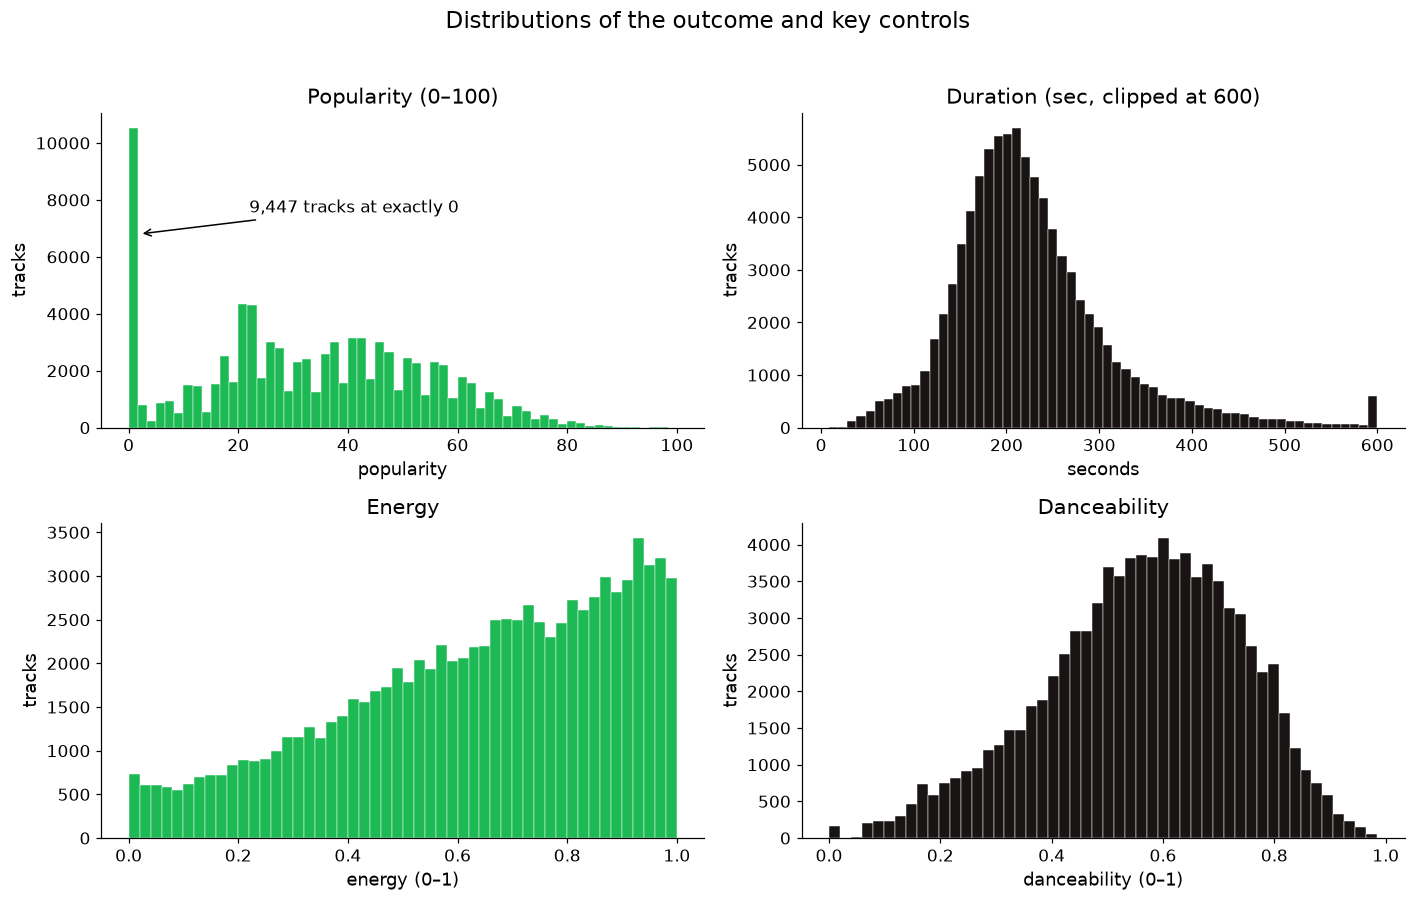

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes[0,0].hist(d['popularity'], bins=60, color=GREEN, edgecolor='white', lw=.3)
axes[0,0].set(title='Popularity (0–100)', xlabel='popularity', ylabel='tracks')
axes[0,0].annotate(f"{(d.popularity==0).sum():,} tracks at exactly 0", xy=(2, (d.popularity==0).sum()*0.72),
                   xytext=(22, (d.popularity==0).sum()*0.8), arrowprops=dict(arrowstyle='->'))
axes[0,1].hist(d['duration_sec'].clip(upper=600), bins=60, color=DARK, edgecolor='white', lw=.3)
axes[0,1].set(title='Duration (sec, clipped at 600)', xlabel='seconds', ylabel='tracks')
axes[1,0].hist(d['energy'], bins=50, color=GREEN, edgecolor='white', lw=.3)
axes[1,0].set(title='Energy', xlabel='energy (0–1)', ylabel='tracks')
axes[1,1].hist(d['danceability'], bins=50, color=DARK, edgecolor='white', lw=.3)
axes[1,1].set(title='Danceability', xlabel='danceability (0–1)', ylabel='tracks')
fig.suptitle('Distributions of the outcome and key controls', y=1.02, fontsize=15)
fig.tight_layout(); fig.savefig(f'{FIGDIR}/fig1_eda_distributions.png', bbox_inches='tight'); plt.show()

## 3. Group comparison — the original analysis, reproduced

This replicates what the original presentation did: compare featured vs. solo tracks directly, test with Mann–Whitney U (popularity is non-normal), and report effect sizes — which the original omitted, and which turn out to matter.

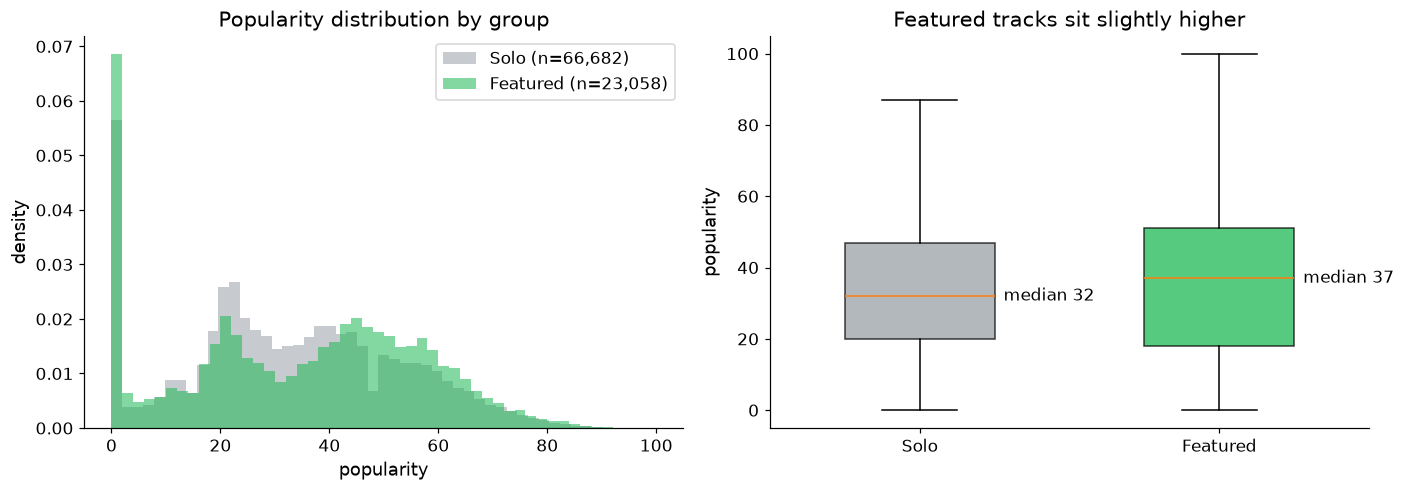

Raw difference in means: +1.41 points  (95% CI [1.09, 1.73])
Mann–Whitney U = 804,366,146, one-sided p = 4.20e-26
Effect sizes: rank-biserial r = 0.046 | Cohen's d = 0.069

Reading: the difference is statistically unambiguous at n≈90k — and tiny.
A d of 0.07 means the two distributions overlap almost completely.


In [4]:
g0 = d.loc[d.has_feature==0, 'popularity']
g1 = d.loc[d.has_feature==1, 'popularity']

U, p_mw = stats.mannwhitneyu(g1, g0, alternative='greater')
rank_biserial = 2*U/(len(g0)*len(g1)) - 1
sd_pooled = np.sqrt(((len(g0)-1)*g0.var() + (len(g1)-1)*g1.var()) / (len(g0)+len(g1)-2))
cohen_d = (g1.mean()-g0.mean()) / sd_pooled
raw_diff = g1.mean() - g0.mean()
se_diff = np.sqrt(g0.var()/len(g0) + g1.var()/len(g1))
raw_ci = (raw_diff - 1.96*se_diff, raw_diff + 1.96*se_diff)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for grp, lab, col in [(g0,'Solo',GREY),(g1,'Featured',GREEN)]:
    axes[0].hist(grp, bins=50, density=True, alpha=.55, label=f'{lab} (n={len(grp):,})', color=col)
axes[0].legend(); axes[0].set(title='Popularity distribution by group', xlabel='popularity', ylabel='density')
bp = axes[1].boxplot([g0, g1], tick_labels=['Solo','Featured'], patch_artist=True, showfliers=False, widths=.5)
for patch, col in zip(bp['boxes'], [GREY, GREEN]): patch.set_facecolor(col); patch.set_alpha(.75)
for i, grp in enumerate([g0, g1], 1):
    axes[1].annotate(f'median {grp.median():.0f}', xy=(i, grp.median()), xytext=(i+0.28, grp.median()), va='center')
axes[1].set(title='Featured tracks sit slightly higher', ylabel='popularity')
fig.tight_layout(); fig.savefig(f'{FIGDIR}/fig2_group_comparison.png', bbox_inches='tight'); plt.show()

print(f"Raw difference in means: +{raw_diff:.2f} points  (95% CI [{raw_ci[0]:.2f}, {raw_ci[1]:.2f}])")
print(f"Mann–Whitney U = {U:,.0f}, one-sided p = {p_mw:.2e}")
print(f"Effect sizes: rank-biserial r = {rank_biserial:.3f} | Cohen's d = {cohen_d:.3f}")
print(f"\nReading: the difference is statistically unambiguous at n≈90k — and tiny.")
print(f"A d of {cohen_d:.2f} means the two distributions overlap almost completely.")
RESULTS['raw'] = dict(diff=raw_diff, ci=list(raw_ci), p=float(p_mw), d=float(cohen_d), rbc=float(rank_biserial))

## 4. The regression our proposal specified

The project proposal planned: *"ordinary least squares linear regression with heteroskedasticity-consistent (HC3) robust standard errors... We will report the estimated effect for has_feature, a 95% confidence interval, a p-value, and a standardized effect size"* — with genre among the controls. The original final presentation stopped at the bivariate comparison. This section completes the plan.

- **Spec 1** uses the controls named in the final presentation's research question: duration, explicitness, energy, danceability.
- **Spec 2** moves toward the proposal's fuller specification: adds valence, loudness, and **genre fixed effects** (114 genres). Release year was in the proposal but is not available in this dataset — a limitation the original team evidently hit too.

In [5]:
m1 = smf.ols('popularity ~ has_feature + duration_sec + explicit + energy + danceability', d).fit(cov_type='HC3')
m2 = smf.ols('popularity ~ has_feature + duration_sec + explicit + energy + danceability + valence + loudness + C(track_genre)', d).fit(cov_type='HC3')

def row(m, label):
    ci = m.conf_int().loc['has_feature']
    return dict(model=label, coef=m.params['has_feature'], lo=ci[0], hi=ci[1],
                p=m.pvalues['has_feature'], r2=m.rsquared)

tab = pd.DataFrame([row(m1, 'Spec 1: duration + explicit + energy + danceability'),
                    row(m2, 'Spec 2: + valence + loudness + genre fixed effects')])
tab['std. effect (share of SD)'] = tab['coef'] / d['popularity'].std()
RESULTS['spec1'] = row(m1,'spec1'); RESULTS['spec2'] = row(m2,'spec2')
tab.round(4)

,model,coef,lo,hi,p,r2,std. effect (share of SD)
0,Spec 1: duration + explicit + energy + danceab...,1.0806,0.7601,1.4011,0.000,0.0072,0.0525
1,Spec 2: + valence + loudness + genre fixed eff...,0.2786,-0.0140,0.5712,0.062,0.3288,0.0135


In [6]:
X = d[['has_feature','duration_sec','explicit','energy','danceability','valence','loudness']].astype(float)
Xz = (X - X.mean())/X.std(); Xz.insert(0, 'const', 1.0)
vif = pd.Series({c: variance_inflation_factor(Xz.values, i) for i, c in enumerate(Xz.columns) if c != 'const'},
                name='VIF').round(2)
print('Multicollinearity check — all VIF well below the conventional threshold of 5:')
print(vif.to_string())

Multicollinearity check — all VIF well below the conventional threshold of 5:
has_feature     1.02
duration_sec    1.04
explicit        1.04
energy          2.45
danceability    1.43
valence         1.45
loudness        2.53


### Why the effect shrinks: a genre decomposition

Genre fixed effects take R² from ~0.01 to ~0.33 and cut the featured-artist coefficient by roughly three quarters. To show the mechanism directly rather than assert it, the raw gap is decomposed **exactly** into two parts using a shift-share decomposition: (1) **genre composition** — the gap that comes from featured tracks concentrating in higher- or lower-popularity genres, holding each genre's solo-track popularity fixed, and (2) the **within-genre gap** — the gap from featured tracks outperforming solo tracks *inside the same genre*, weighted by where featured tracks sit. These two terms sum exactly to the raw gap (no residual) by construction — unlike a naive version of this decomposition that compares each group's exposure to the *blended* genre-level mean, which leaves an unexplained gap because that blended mean already bakes in part of the within-genre effect. If collaborations themselves drove popularity, the within-genre term would carry the gap.

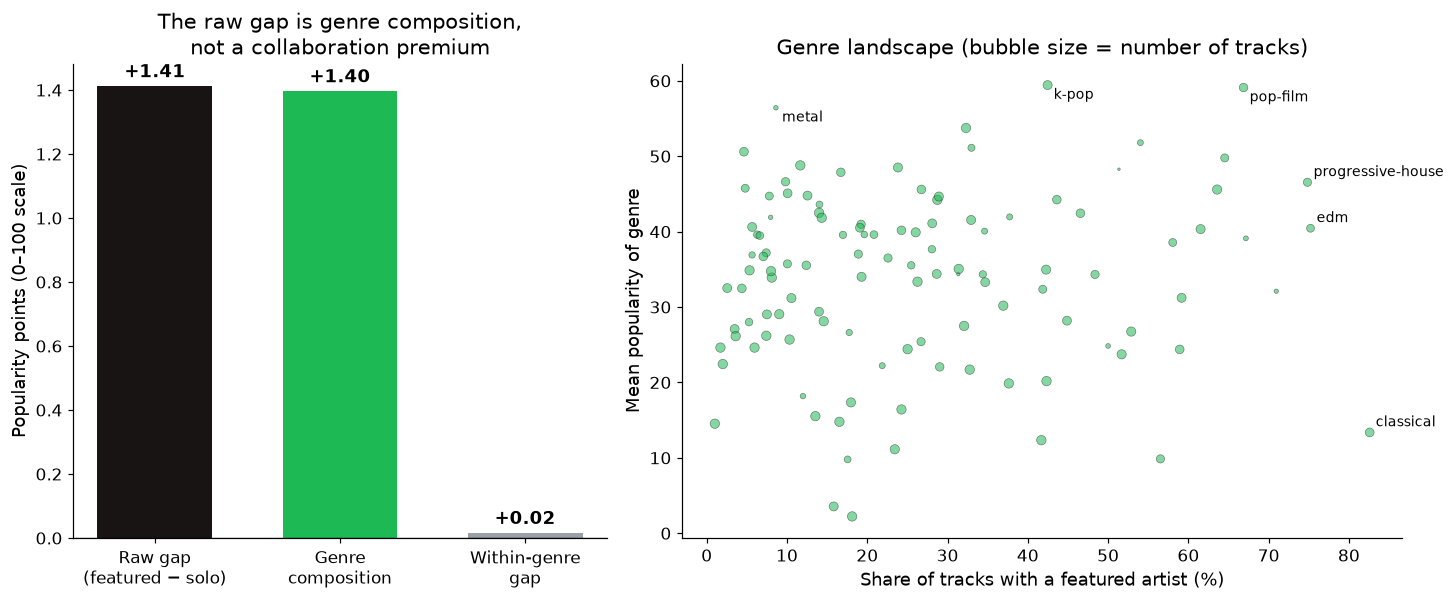

Raw featured-vs-solo gap:  +1.41 points
  Genre composition:      +1.40 points  (99% of the raw gap)
  Within-genre gap:       +0.02 points  (1% of the raw gap)

Composition + within sum exactly to the raw gap: +1.40 + +0.02 = +1.41
Inside the same genre, featured and solo tracks are essentially equally popular.


In [7]:
# Decompose the raw gap: genre composition vs within-genre difference.
# Exact shift-share decomposition (no residual): raw_gap = composition + within.
#   composition = sum_g (p1_g - p0_g) * m0_g   -- gap from featured tracks sitting in different genres
#   within      = sum_g p1_g * (m1_g - m0_g)   -- gap from featured vs solo *inside* the same genre
raw_gap = g1.mean() - g0.mean()
n1 = d[d.has_feature==1].groupby('track_genre').size()
n0 = d[d.has_feature==0].groupby('track_genre').size()
m1 = d[d.has_feature==1].groupby('track_genre')['popularity'].mean()
m0 = d[d.has_feature==0].groupby('track_genre')['popularity'].mean()
assert n1.index.equals(n0.index), "some genres are missing one group"
p1, p0 = n1 / n1.sum(), n0 / n0.sum()

composition = ((p1 - p0) * m0).sum()
within_w = (p1 * (m1 - m0)).sum()
assert abs((composition + within_w) - raw_gap) < 1e-9
RESULTS['decomp'] = dict(raw=float(raw_gap), between=float(composition), within=float(within_w))

g = d.groupby('track_genre').agg(mean_pop=('popularity','mean'),
                                 feat_share=('has_feature','mean'),
                                 n=('popularity','size')).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.6), gridspec_kw={'width_ratios':[1,1.35]})
bars = axes[0].bar(['Raw gap\n(featured − solo)','Genre\ncomposition','Within-genre\ngap'],
                   [raw_gap, composition, within_w], color=[DARK, GREEN, GREY], width=.62)
for b, v in zip(bars, [raw_gap, composition, within_w]):
    axes[0].annotate(f'{v:+.2f}', (b.get_x()+b.get_width()/2, v), ha='center', va='bottom',
                     fontsize=12, fontweight='bold', xytext=(0,3), textcoords='offset points')
axes[0].axhline(0, color='black', lw=.8)
axes[0].set(ylabel='Popularity points (0–100 scale)',
            title='The raw gap is genre composition,\nnot a collaboration premium')
axes[1].scatter(g['feat_share']*100, g['mean_pop'], s=g['n']/26, alpha=.55, color=GREEN, edgecolor=DARK, lw=.4)
for _, rw in g.nlargest(3,'feat_share').iterrows():
    axes[1].annotate(rw.track_genre, (rw.feat_share*100, rw.mean_pop), fontsize=9, xytext=(4,4), textcoords='offset points')
for _, rw in g.nlargest(3,'mean_pop').iterrows():
    axes[1].annotate(rw.track_genre, (rw.feat_share*100, rw.mean_pop), fontsize=9, xytext=(4,-9), textcoords='offset points')
axes[1].set(xlabel='Share of tracks with a featured artist (%)', ylabel='Mean popularity of genre',
            title='Genre landscape (bubble size = number of tracks)')
fig.tight_layout(); fig.savefig(f'{FIGDIR}/fig3_genre_composition.png', bbox_inches='tight'); plt.show()

print(f'Raw featured-vs-solo gap:  {raw_gap:+.2f} points')
print(f'  Genre composition:      {composition:+.2f} points  ({composition/raw_gap:.0%} of the raw gap)')
print(f'  Within-genre gap:       {within_w:+.2f} points  ({within_w/raw_gap:.0%} of the raw gap)')
print(f'\nComposition + within sum exactly to the raw gap: {composition:+.2f} + {within_w:+.2f} = {composition+within_w:+.2f}')
print(f'Inside the same genre, featured and solo tracks are essentially equally popular.')

## 5. Robustness

The proposal planned robustness checks over the "featured" detection rule and sample choices. Four variants, all re-estimated on Spec 2:
1. **Substring rule** — `feat`/`with` anywhere in the title (looser than word-boundary).
2. **`&` counted as a collaboration marker** — closest to the original team's larger featured count.
3. **Excluding popularity = 0** — removes the zero-inflation spike.
4. **Excluding remix / live / acoustic / remaster versions** — the proposal's planned exclusion.

In [8]:
def refit(dd, label):
    m = smf.ols('popularity ~ has_feature + duration_sec + explicit + energy + danceability + valence + loudness + C(track_genre)', dd).fit(cov_type='HC3')
    ci = m.conf_int().loc['has_feature']
    return dict(model=label, coef=m.params['has_feature'], lo=ci[0], hi=ci[1], p=m.pvalues['has_feature'], n=len(dd))

rob = []
d_sub = d.copy(); d_sub['has_feature'] = (d.multi_artist | t.str.contains('feat') | t.str.contains('with')).astype(int)
rob.append(refit(d_sub, 'Substring feat/with rule'))
d_amp = d.copy(); d_amp['has_feature'] = (d.multi_artist | d.title_feat | a.str.contains('&')).astype(int)
rob.append(refit(d_amp, "'&' counted as collaboration"))
rob.append(refit(d[d.popularity > 0], 'Excluding popularity = 0'))
mask = ~t.str.contains(r'\b(?:remix|live|acoustic|remaster)', regex=True)
rob.append(refit(d[mask], 'Excluding remix/live/acoustic/remaster'))
rob_df = pd.DataFrame(rob); RESULTS['robust'] = rob
rob_df.round(4)

,model,coef,lo,hi,p,n
0,Substring feat/with rule,0.2262,-0.0666,0.5190,0.1300,89740
1,'&' counted as collaboration,0.1707,-0.1151,0.4565,0.2417,89740
2,Excluding popularity = 0,0.3349,0.0920,0.5777,0.0069,80293
3,Excluding remix/live/acoustic/remaster,0.4558,0.1510,0.7606,0.0034,84522


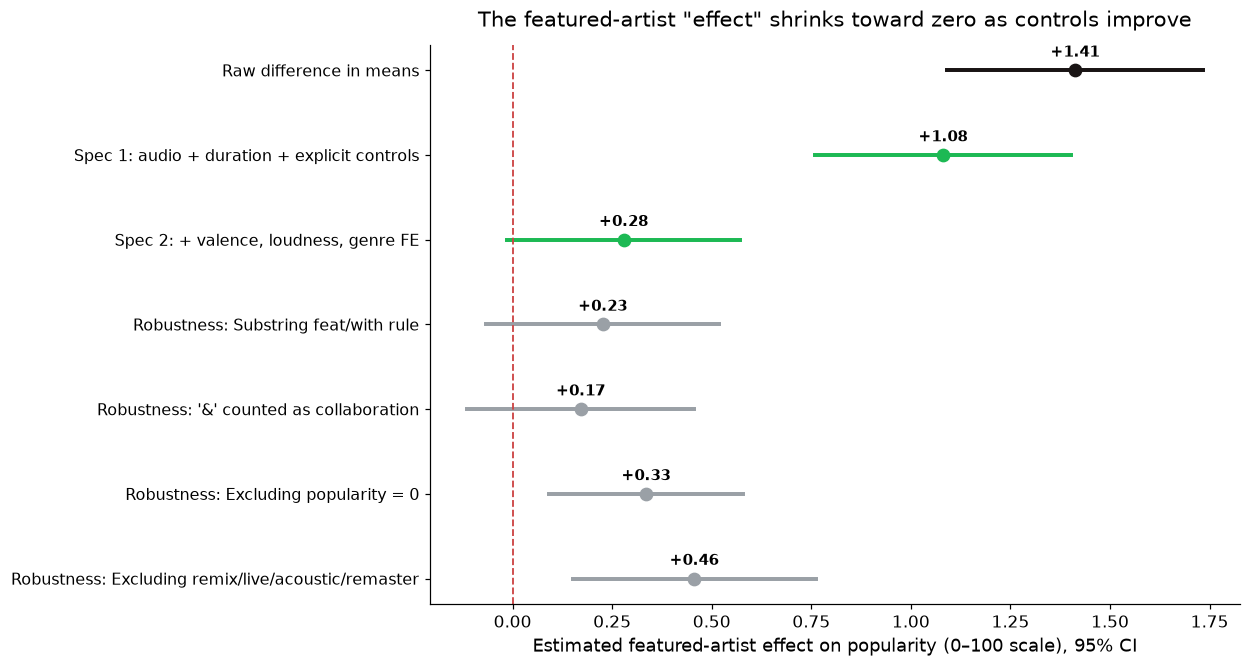

In [9]:
rows = ([('Raw difference in means', RESULTS['raw']['diff'], *RESULTS['raw']['ci'])] +
        [('Spec 1: audio + duration + explicit controls', RESULTS['spec1']['coef'], RESULTS['spec1']['lo'], RESULTS['spec1']['hi']),
         ('Spec 2: + valence, loudness, genre FE', RESULTS['spec2']['coef'], RESULTS['spec2']['lo'], RESULTS['spec2']['hi'])] +
        [(f"Robustness: {r['model']}", r['coef'], r['lo'], r['hi']) for r in RESULTS['robust']])

fig, ax = plt.subplots(figsize=(11.5, 6.2))
ys = np.arange(len(rows))[::-1]
for y, (lab, c, lo, hi) in zip(ys, rows):
    col = DARK if 'Raw' in lab else (GREEN if 'Spec' in lab else GREY)
    ax.plot([lo, hi], [y, y], color=col, lw=2.6)
    ax.plot(c, y, 'o', color=col, ms=8)
    ax.annotate(f'{c:+.2f}', (c, y), xytext=(0, 9), textcoords='offset points', ha='center', fontsize=10, fontweight='bold')
ax.axvline(0, color='#cc4444', lw=1.2, ls='--')
ax.set_yticks(ys); ax.set_yticklabels([r[0] for r in rows], fontsize=10.5)
ax.set_xlabel('Estimated featured-artist effect on popularity (0–100 scale), 95% CI')
ax.set_title('The featured-artist "effect" shrinks toward zero as controls improve', fontsize=14, pad=12)
fig.tight_layout(); fig.savefig(f'{FIGDIR}/fig4_effect_across_specs.png', bbox_inches='tight'); plt.show()

with open('../results/summary.json', 'w') as f: json.dump(RESULTS, f, indent=2, default=float)

## 6. Conclusion

**What the original presentation said:** *"Featured artists meaningfully boost visibility and popularity on Spotify... collaborations strategically elevate track success"* (p ≈ 1e-29).

**What the completed analysis shows:** the raw gap is real but tiny (+1.4 points on a 0–100 scale, Cohen's d ≈ 0.07), and an exact decomposition attributes **99% of it to genre composition**: featured tracks sit in genres whose average popularity is +1.40 points higher, while the within-genre featured-vs-solo gap is +0.02 — effectively zero. Controlling for genre and audio features, the featured-artist coefficient is +0.28 points (95% CI −0.01 to +0.57, p = 0.06) — between roughly zero and half a point across every robustness variant. At n ≈ 90,000, statistical significance is nearly guaranteed for any nonzero difference; the analytical question was always effect *size*, and the honest answer is: negligible within genre, in this catalog snapshot.

**Why this differs from prior stream-based studies** (e.g., reports of ≥5% more streams for collaborations): different outcome (Spotify's recency-weighted popularity score vs. stream counts), different sample (a broad catalog snapshot vs. new chart releases), and — critically — **artist fame is unobserved here**. Famous artists both collaborate more and are more popular, which would bias this estimate *upward*; that the adjusted effect is still near zero makes the null-ish result more, not less, credible for this setting.

**Limitations:** popularity is a platform-defined, recency-weighted score (results describe Spotify's metric, not intrinsic quality); genre is one label per track from the source dataset's playlist assignment; release year is unavailable; the data are a snapshot, so we cannot see popularity trajectories; and no causal claim is possible — artists choose when to collaborate.

**What I changed relative to the original team deliverable:** completed the proposal's planned OLS + HC3 + effect sizes + robustness; added genre fixed effects and the composition analysis; replaced "meaningfully boost" with an effect-size-honest interpretation. The original raw comparison was correct as computed — the conclusion drawn from it was stronger than the evidence.